<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/MNIST_adi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-image -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)
from sklearn.cluster import MiniBatchKMeans

from skimage.feature import local_binary_pattern
from skimage.feature import hog
from scipy.ndimage import rotate, shift

import warnings
warnings.filterwarnings("ignore")

In [ ]:
mnist = fetch_openml('mnist_784',version=1,as_frame=False,parser='auto')
X = mnist.data.astype(np.float32)
y = mnist.target.astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70000, 784)
y shape: (70000,)


In [ ]:
X = X / 255.0
X_images = X.reshape(-1, 28, 28)
print(X_images.shape)

(70000, 28, 28)


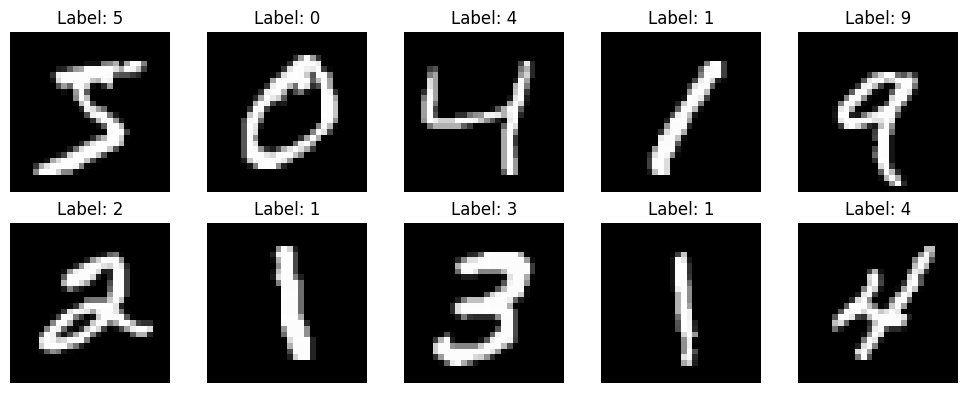

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.ravel()):
    ax.imshow(X_images[i], cmap="gray")
    ax.set_title(f"Label: {y[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_images,y,test_size=0.2,random_state=42,stratify=y)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (56000, 28, 28)
Testing : (14000, 28, 28)


In [ ]:
def augment_rotation(images, labels, angle=15):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        aug_img = rotate(img,angle=angle,reshape=False,mode='constant',cval=0)
        augmented_images.append(aug_img)
        augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

In [ ]:
def augment_shift(images, labels, shift_pixels=2):
    augmented_images = []
    augmented_labels = []

    for img, label in zip(images, labels):
        aug_img = shift(img,shift=(shift_pixels, shift_pixels),mode='constant',cval=0)
        augmented_images.append(aug_img)
        augmented_labels.append(label)

    return np.array(augmented_images), np.array(augmented_labels)

In [ ]:
AUG_SIZE = 10000

X_aug_base = X_train[:AUG_SIZE]
y_aug_base = y_train[:AUG_SIZE]

X_rot, y_rot = augment_rotation(X_aug_base,y_aug_base,angle=15)
X_shift, y_shift = augment_shift( X_aug_base, y_aug_base, shift_pixels=2)

print(X_rot.shape)
print(X_shift.shape)

(10000, 28, 28)
(10000, 28, 28)


In [ ]:
X_train_aug = np.concatenate([X_train,X_rot,X_shift])
y_train_aug = np.concatenate([y_train,y_rot,y_shift])

print("Original training:", X_train.shape)
print("Augmented training:", X_train_aug.shape)

Original training: (56000, 28, 28)
Augmented training: (76000, 28, 28)


In [ ]:
X_train_flat = X_train_aug.reshape(len(X_train_aug), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

print(X_train_flat.shape)
print(X_test_flat.shape)

(76000, 784)
(14000, 784)


In [ ]:
logistic_raw = LogisticRegression(max_iter=100,solver='lbfgs',n_jobs=-1)
logistic_raw.fit(X_train_flat, y_train_aug)
y_pred = logistic_raw.predict(X_test_flat)
accuracy = accuracy_score(y_test, y_pred)

print("Raw Pixel Logistic Regression Accuracy:",accuracy)

Raw Pixel Logistic Regression Accuracy: 0.9031428571428571


In [ ]:
pca = PCA(n_components=100,random_state=42)
X_train_pca = pca.fit_transform(X_train_flat)
X_test_pca = pca.transform(X_test_flat)

print("Original features:", X_train_flat.shape[1])
print("PCA features:", X_train_pca.shape[1])

Original features: 784
PCA features: 100


In [ ]:
explained_variance = np.sum(pca.explained_variance_ratio_)
print("Variance retained:",explained_variance)

Variance retained: 0.9123815


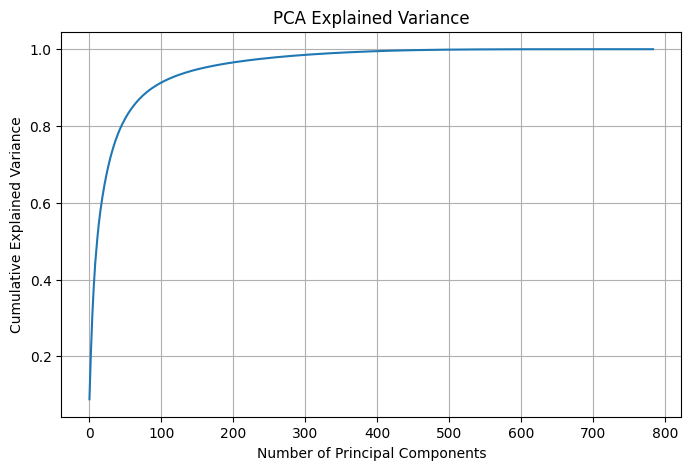

In [ ]:
pca_full = PCA().fit(X_train_flat)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

In [ ]:
logistic_pca = LogisticRegression(max_iter=100,solver='lbfgs',n_jobs=-1)
logistic_pca.fit(X_train_pca,y_train_aug)
y_pred_pca = logistic_pca.predict(X_test_pca)
accuracy_pca = accuracy_score(y_test,y_pred_pca)

print("PCA + Logistic Regression Accuracy:",accuracy_pca)

PCA + Logistic Regression Accuracy: 0.899


In [ ]:
rf_pca = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_pca.fit(X_train_pca,y_train_aug)
y_pred_rf_pca = rf_pca.predict(X_test_pca)
accuracy_rf_pca = accuracy_score(y_test,y_pred_rf_pca)

print("PCA + Random Forest Accuracy:",accuracy_rf_pca)

PCA + Random Forest Accuracy: 0.9533571428571429


In [ ]:
def extract_lbp_features(images, P=8, R=1):
    features = []

    for img in images:

        lbp = local_binary_pattern(
            img,
            P,
            R,
            method='uniform'
        )

        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, P + 3),
            range=(0, P + 2)
        )

        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-6)

        features.append(hist)

    return np.array(features)

In [ ]:
X_train_lbp = extract_lbp_features(
    X_train_aug
)

X_test_lbp = extract_lbp_features(
    X_test
)

print("LBP train shape:", X_train_lbp.shape)
print("LBP test shape :", X_test_lbp.shape)

LBP train shape: (76000, 10)
LBP test shape : (14000, 10)


In [ ]:
rf_lbp = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_lbp.fit(
    X_train_lbp,
    y_train_aug
)

y_pred_lbp = rf_lbp.predict(
    X_test_lbp
)

accuracy_lbp = accuracy_score(
    y_test,
    y_pred_lbp
)

print(
    "LBP + Random Forest Accuracy:",
    accuracy_lbp
)

LBP + Random Forest Accuracy: 0.4295


In [ ]:
def extract_hog_features(images):
    features = []

    for img in images:

        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        features.append(hog_feature)

    return np.array(features)

In [ ]:
def extract_hog_features(images):
    features = []

    for img in images:

        hog_feature = hog(
            img,
            orientations=9,
            pixels_per_cell=(4, 4),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )

        features.append(hog_feature)

    return np.array(features)

In [ ]:
X_train_hog = extract_hog_features(
    X_train_aug
)

X_test_hog = extract_hog_features(
    X_test
)

print("HOG train shape:", X_train_hog.shape)
print("HOG test shape :", X_test_hog.shape)

HOG train shape: (76000, 1296)
HOG test shape : (14000, 1296)


In [ ]:
rf_hog = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_hog.fit(
    X_train_hog,
    y_train_aug
)

y_pred_hog = rf_hog.predict(
    X_test_hog
)

accuracy_hog = accuracy_score(
    y_test,
    y_pred_hog
)

print(
    "HOG + Random Forest Accuracy:",
    accuracy_hog
)

HOG + Random Forest Accuracy: 0.9737142857142858


In [ ]:
logistic_hog = LogisticRegression(
    max_iter=200,
    solver='lbfgs',
    n_jobs=-1
)

logistic_hog.fit(
    X_train_hog,
    y_train_aug
)

y_pred_hog_lr = logistic_hog.predict(
    X_test_hog
)

accuracy_hog_lr = accuracy_score(
    y_test,
    y_pred_hog_lr
)

print(
    "HOG + Logistic Regression Accuracy:",
    accuracy_hog_lr
)

HOG + Logistic Regression Accuracy: 0.9795714285714285


In [ ]:
def extract_patches(images, patch_size=4):
    patches = []

    for img in images:

        h, w = img.shape

        for i in range(0, h - patch_size + 1, patch_size):
            for j in range(0, w - patch_size + 1, patch_size):

                patch = img[
                    i:i+patch_size,
                    j:j+patch_size
                ]

                patches.append(
                    patch.flatten()
                )

    return np.array(patches)

In [ ]:
# Use subset for vocabulary creation
X_vocab = X_train_aug[:5000]

patches = extract_patches(
    X_vocab,
    patch_size=4
)

print("Patch shape:", patches.shape)

Patch shape: (245000, 16)


In [ ]:
VOCAB_SIZE = 50

kmeans = MiniBatchKMeans(
    n_clusters=VOCAB_SIZE,
    random_state=42,
    batch_size=2048,
    n_init=3
)

kmeans.fit(patches)

print("Visual vocabulary created.")

Visual vocabulary created.


In [ ]:
def image_to_bovw(images, kmeans, patch_size=4):

    all_features = []

    for img in images:

        patches = []

        h, w = img.shape

        for i in range(
            0,
            h - patch_size + 1,
            patch_size
        ):
            for j in range(
                0,
                w - patch_size + 1,
                patch_size
            ):

                patch = img[
                    i:i+patch_size,
                    j:j+patch_size
                ]

                patches.append(
                    patch.flatten()
                )

        patches = np.array(patches)

        visual_words = kmeans.predict(
            patches
        )

        histogram = np.bincount(
            visual_words,
            minlength=kmeans.n_clusters
        )

        histogram = histogram.astype(
            np.float32
        )

        histogram /= (
            histogram.sum() + 1e-6
        )

        all_features.append(histogram)

    return np.array(all_features)

In [ ]:
X_train_bow = image_to_bovw(
    X_train_aug,
    kmeans
)

X_test_bow = image_to_bovw(
    X_test,
    kmeans
)

print("BoVW train:", X_train_bow.shape)
print("BoVW test :", X_test_bow.shape)

BoVW train: (76000, 50)
BoVW test : (14000, 50)


In [ ]:
rf_bow = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_bow.fit(
    X_train_bow,
    y_train_aug
)

y_pred_bow = rf_bow.predict(
    X_test_bow
)

accuracy_bow = accuracy_score(
    y_test,
    y_pred_bow
)

print(
    "BoVW + Random Forest Accuracy:",
    accuracy_bow
)

BoVW + Random Forest Accuracy: 0.5042142857142857


In [ ]:
logistic_bow = LogisticRegression(
    max_iter=200,
    solver='lbfgs',
    n_jobs=-1
)

logistic_bow.fit(
    X_train_bow,
    y_train_aug
)

y_pred_bow_lr = logistic_bow.predict(
    X_test_bow
)

accuracy_bow_lr = accuracy_score(
    y_test,
    y_pred_bow_lr
)

print(
    "BoVW + Logistic Regression Accuracy:",
    accuracy_bow_lr
)

BoVW + Logistic Regression Accuracy: 0.4664285714285714


In [ ]:
results = pd.DataFrame({
    "Feature": [
        "Raw Pixels",
        "PCA",
        "PCA",
        "LBP",
        "HOG",
        "HOG",
        "BoVW",
        "BoVW"
    ],

    "Classifier": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest",
        "Random Forest",
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression"
    ],

    "Accuracy": [
        accuracy,
        accuracy_pca,
        accuracy_rf_pca,
        accuracy_lbp,
        accuracy_hog,
        accuracy_hog_lr,
        accuracy_bow,
        accuracy_bow_lr
    ]
})

results = results.sort_values(
    "Accuracy",
    ascending=False
)

results

,Feature,Classifier,Accuracy
5,HOG,Logistic Regression,0.979571
4,HOG,Random Forest,0.973714
2,PCA,Random Forest,0.953357
0,Raw Pixels,Logistic Regression,0.903143
1,PCA,Logistic Regression,0.899000
6,BoVW,Random Forest,0.504214
7,BoVW,Logistic Regression,0.466429
3,LBP,Random Forest,0.429500


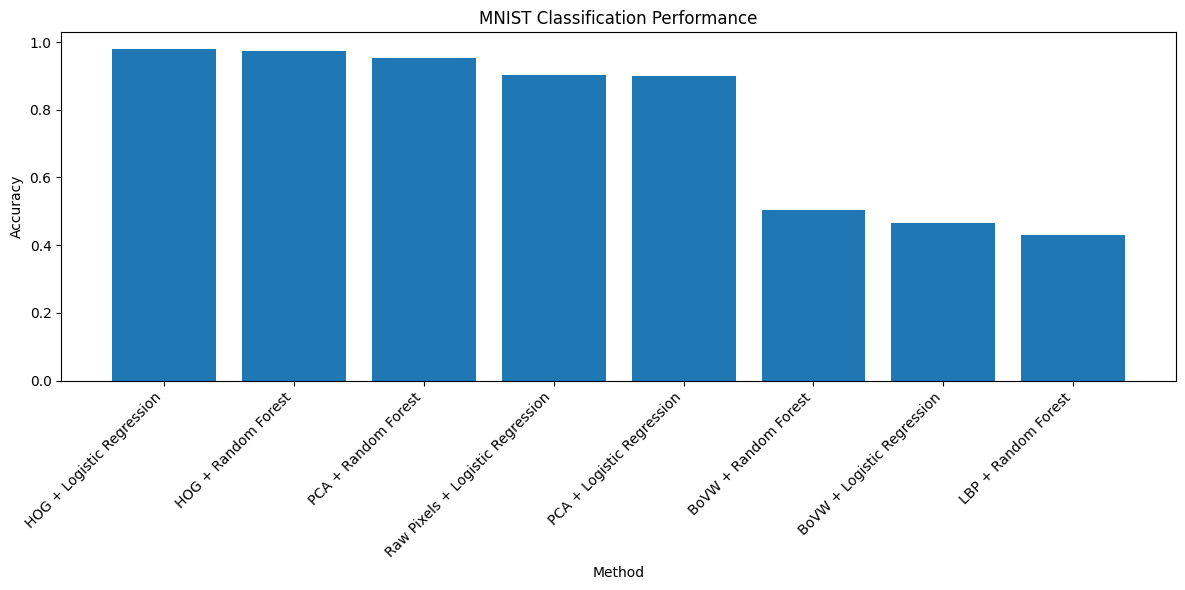

In [ ]:
plt.figure(figsize=(12, 6))

labels = (
    results["Feature"]
    + " + "
    + results["Classifier"]
)

plt.bar(
    labels,
    results["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Method")
plt.title("MNIST Classification Performance")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_hog
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.97      0.98      0.97      1398
           3       0.95      0.97      0.96      1428
           4       0.97      0.97      0.97      1365
           5       0.98      0.97      0.97      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.98      0.96      0.97      1365
           9       0.97      0.95      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000

